# <span style="color:red">  Daily Data - EBC creation, FMB Quantiles (1970 - 2024)

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Daily EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Raw returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_daily_with_tickers.csv",
    market_caps_file="sp500_market_caps_daily.csv",
    ff_factors_file="ff_factors_daily.csv",
    frequency="daily"
)

# Use raw (non-excess) EBC and CW-EBC spread
ebc = full_merged_df["EBC"]
cw_ebc = full_merged_df["CW"] - full_merged_df["EBC"]

Rolling OLS CAPM:   0%|          | 0/15229 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/15229 [00:00<?, ?it/s]

Hey fixing full investment every period


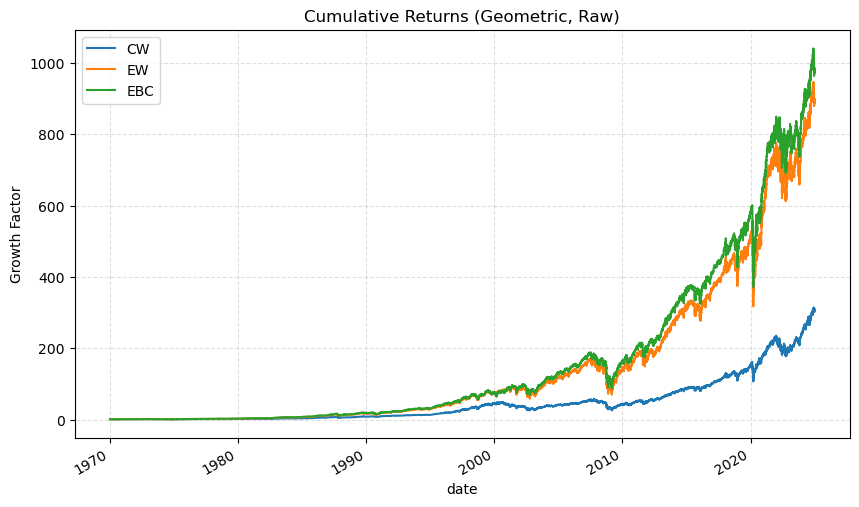

In [5]:
plot_df = full_merged_df[['CW', 'EW', 'EBC']].loc['1970':]
if isinstance(plot_df.index, pd.PeriodIndex):
    plot_df.index = plot_df.index.to_timestamp()
(1 + plot_df).cumprod().plot(figsize=(10, 6))
plt.title("Cumulative Returns (Geometric, Raw)")
plt.ylabel("Growth Factor")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [6]:
full_merged_df['MKT'] = full_merged_df['MKT_RF'] + full_merged_df['RF']

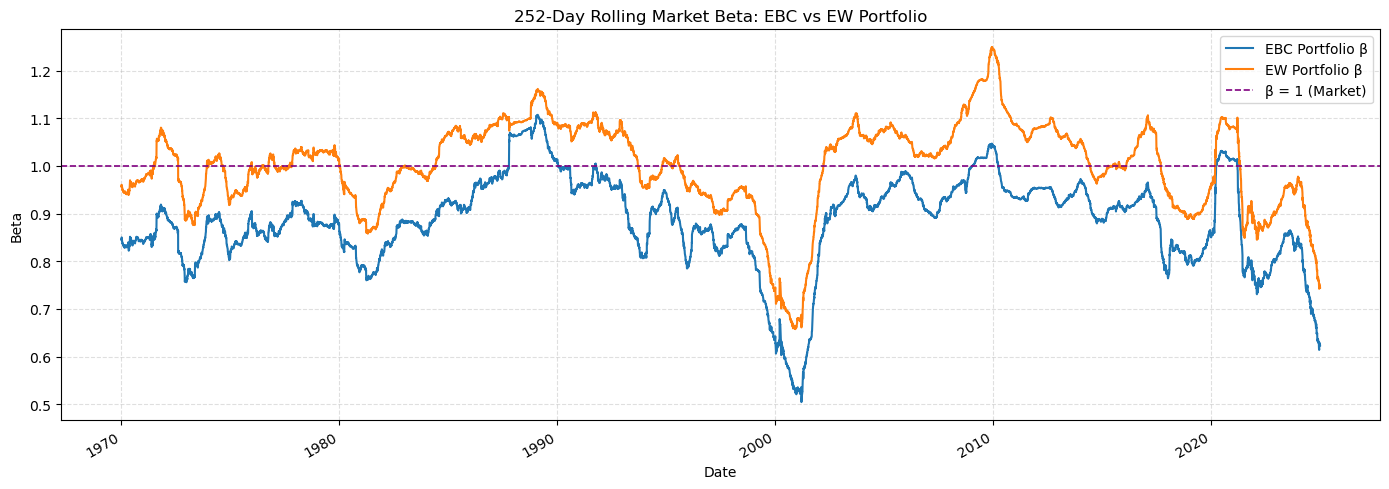


── Rolling Beta Summary ──
           EBC β       EW β
count  13871.000  13871.000
mean       0.885      1.001
std        0.095      0.094
min        0.505      0.658
25%        0.836      0.948
50%        0.891      1.015
75%        0.946      1.069
max        1.107      1.249


In [7]:
import statsmodels.api as sm

# ── Rolling 252-day Market Beta: EBC vs EW ──
window = 252

ebc_ret = full_merged_df["EBC"].copy()
ew_ret  = full_merged_df["EW"].copy()
mkt     = full_merged_df["MKT"].copy()

if isinstance(ebc_ret.index, pd.PeriodIndex):
    ebc_ret.index = ebc_ret.index.to_timestamp()
    ew_ret.index  = ew_ret.index.to_timestamp()
if isinstance(mkt.index, pd.PeriodIndex):
    mkt.index = mkt.index.to_timestamp()

combined = pd.DataFrame({
    "EBC": ebc_ret,
    "EW":  ew_ret,
    "MKT": mkt
}).dropna()

beta_ebc, beta_ew, dates = [], [], []

for i in range(window, len(combined) + 1):
    w = combined.iloc[i - window:i]
    X = sm.add_constant(w["MKT"])
    try:
        beta_ebc.append(sm.OLS(w["EBC"], X).fit().params["MKT"])
        beta_ew.append( sm.OLS(w["EW"],  X).fit().params["MKT"])
    except Exception:
        beta_ebc.append(np.nan)
        beta_ew.append(np.nan)
    dates.append(combined.index[i - 1])

beta_df = pd.DataFrame({"EBC β": beta_ebc, "EW β": beta_ew}, index=dates)

plot_beta = beta_df.loc['1970':]

plt.figure(figsize=(14, 5))
plot_beta["EBC β"].plot(linewidth=1.5, label="EBC Portfolio β", color="tab:blue")
plot_beta["EW β"].plot( linewidth=1.5, label="EW Portfolio β",  color="tab:orange")
plt.axhline(1.0, color="purple", linestyle="--", linewidth=1.2, label="β = 1 (Market)")
plt.title("252-Day Rolling Market Beta: EBC vs EW Portfolio")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n── Rolling Beta Summary ──")
print(plot_beta.describe().round(3))

Correlation (EBC vs EW)       : 0.991796
Mean daily return difference         : -0.0005%  (-0.13% annualized)
Std of daily return difference       : 0.1760%
Max daily divergence                 : 1.8152%
EBC annualized mean return    : 13.7698%
EW  annualized mean return    : 13.9008%


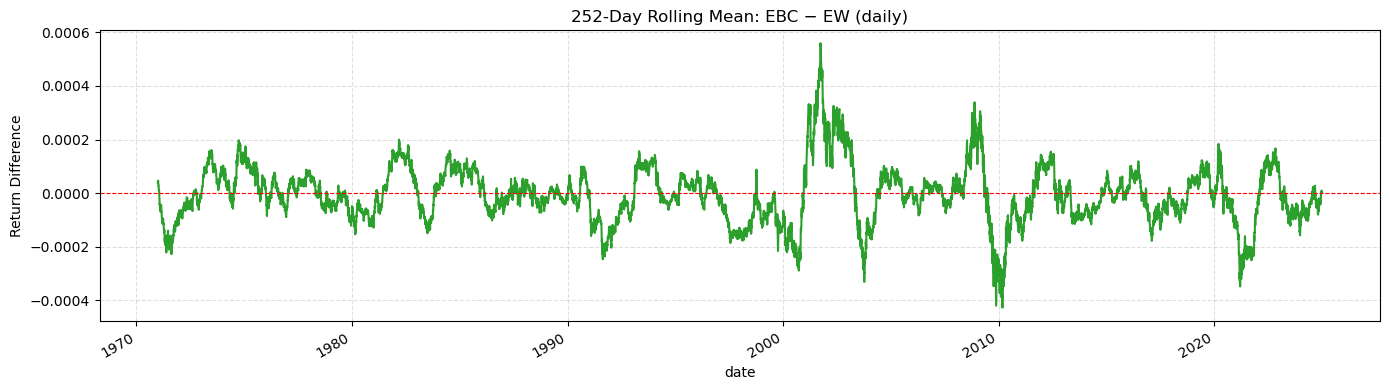

In [8]:
# ── EBC vs EW: are they actually the same portfolio? ──
comp = pd.DataFrame({
    "EBC": full_merged_df["EBC"],
    "EW":  full_merged_df["EW"]
})

comp = comp['1970':]
if isinstance(comp.index, pd.PeriodIndex):
    comp.index = comp.index.to_timestamp()
comp = comp.dropna()

corr = comp["EBC"].corr(comp["EW"])
diff = (comp["EBC"] - comp["EW"])

print(f"Correlation (EBC vs EW)       : {corr:.6f}")
print(f"Mean daily return difference         : {diff.mean()*100:.4f}%  ({diff.mean()*25200:.2f}% annualized)")
print(f"Std of daily return difference       : {diff.std()*100:.4f}%")
print(f"Max daily divergence                 : {diff.abs().max()*100:.4f}%")
print(f"EBC annualized mean return    : {comp['EBC'].mean()*252:.4%}")
print(f"EW  annualized mean return    : {comp['EW'].mean()*252:.4%}")

# Plot 252-day rolling mean difference (full sample)
diff.rolling(252).mean().plot(figsize=(14,4), linewidth=1.5, color="tab:green")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.title("252-Day Rolling Mean: EBC − EW (daily)")
plt.ylabel("Return Difference")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# <span style="color:red">  Get rolling betas for the two focus portfolios EBC and CW - EBC

#### create factor returns

In [9]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

# Convert to timestamp to match asset_returns index
if isinstance(ebc.index, pd.PeriodIndex):
    ebc.index = ebc.index.to_timestamp()
if isinstance(cw_ebc.index, pd.PeriodIndex):
    cw_ebc.index = cw_ebc.index.to_timestamp()

factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()

#### get asset returns (raw, no RF subtraction)

In [10]:
asset_returns, caps_df, ff_factors = fmb_pipe.load_daily_inputs(DATA_RAW_DIR, excess=False)

#### compute rolling betas for EBC and CW-EBC

In [11]:
asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = fmb_betas.compute_rolling_betas(asset_returns, ebc, rolling_window=252, min_obs=100)
betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_returns, cw_ebc, rolling_window=252, min_obs=100)

Estimating rolling betas: 100%|██████████| 14955/14955 [25:55<00:00,  9.61it/s]


=== Beta Coverage ===
EBC betas   : (14955, 1969)  |  date range: 1965-08-03 → 2024-12-31
CW-EBC betas: (14955, 1969)  |  date range: 1965-08-03 → 2024-12-31

=== Average non-NaN assets per period (first 5 / last 5) ===
EBC betas:
date
1965-08-03    470
1965-08-04    470
1965-08-05    470
1965-08-06    470
1965-08-09    470
2024-12-24    484
2024-12-26    484
2024-12-27    484
2024-12-30    484
2024-12-31    484
CW-EBC betas:
date
1965-08-03    470
1965-08-04    470
1965-08-05    470
1965-08-06    470
1965-08-09    470
2024-12-24    484
2024-12-26    484
2024-12-27    484
2024-12-30    484
2024-12-31    484

=== Cross-sectional distribution (all dates stacked) ===
           EBC beta   CW-EBC beta
count  7.006690e+06  7.006690e+06
mean   1.103000e+00  6.260000e-01
std    4.210000e-01  1.379400e+00
min    1.547000e-01 -4.157900e+00
25%    8.210000e-01 -1.542000e-01
50%    1.061300e+00  5.615000e-01
75%    1.334200e+00  1.404200e+00
max    2.615100e+00  5.084800e+00

=== Extreme EBC beta

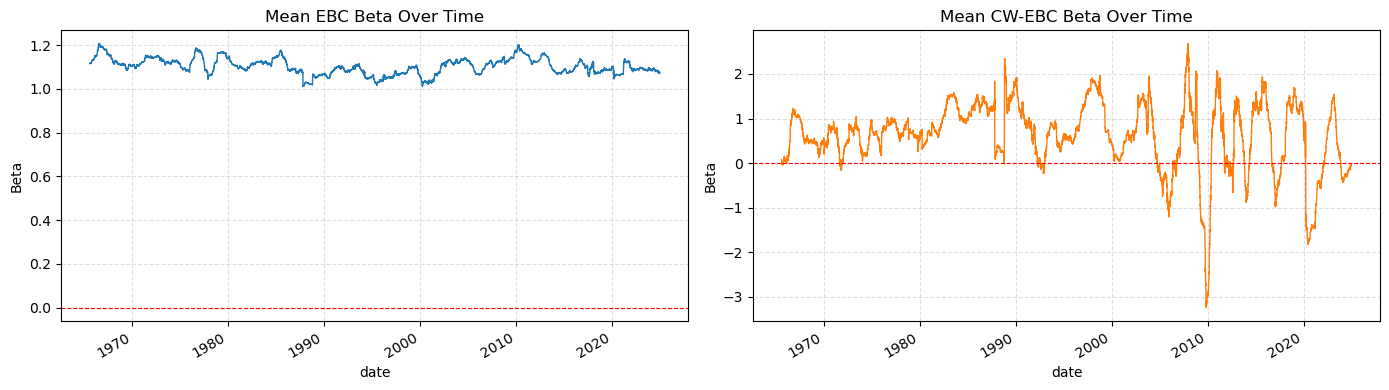

In [12]:
# ── Basic beta sanity checks ──

print("=== Beta Coverage ===")
print(f"EBC betas   : {betas_ebc.shape}  |  date range: {betas_ebc.index.min().date()} → {betas_ebc.index.max().date()}")
print(f"CW-EBC betas: {betas_cw_ebc.shape}  |  date range: {betas_cw_ebc.index.min().date()} → {betas_cw_ebc.index.max().date()}")

print("\n=== Average non-NaN assets per period (first 5 / last 5) ===")
ebc_coverage   = betas_ebc.notna().sum(axis=1)
cwebc_coverage = betas_cw_ebc.notna().sum(axis=1)
print("EBC betas:")
print(pd.concat([ebc_coverage.head(), ebc_coverage.tail()]).to_string())
print("CW-EBC betas:")
print(pd.concat([cwebc_coverage.head(), cwebc_coverage.tail()]).to_string())

print("\n=== Cross-sectional distribution (all dates stacked) ===")
ebc_flat   = betas_ebc.stack(future_stack=True).dropna()
cwebc_flat = betas_cw_ebc.stack(future_stack=True).dropna()
print(pd.DataFrame({
    "EBC beta": ebc_flat.describe(),
    "CW-EBC beta": cwebc_flat.describe()
}).round(4))

print("\n=== Extreme EBC beta values (post-1970 only) ===")
ebc_post70 = betas_ebc.loc["1970-01":].stack(future_stack=True).dropna()
print(ebc_post70.quantile([0.99, 0.995, 0.999]).round(4))

print("\n=== Cross-correlation between mean EBC beta and mean CW-EBC beta (should be low) ===")
mean_betas = pd.DataFrame({
    "mean_EBC": betas_ebc.mean(axis=1),
    "mean_CW_EBC": betas_cw_ebc.mean(axis=1)
}).dropna()
print(mean_betas.corr().round(3))

# ── Time-series plot of cross-sectional mean betas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean_betas["mean_EBC"].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Mean EBC Beta Over Time")
axes[0].set_ylabel("Beta")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].grid(True, linestyle="--", alpha=0.4)

mean_betas["mean_CW_EBC"].plot(ax=axes[1], linewidth=1, color="tab:orange")
axes[1].set_title("Mean CW-EBC Beta Over Time")
axes[1].set_ylabel("Beta")
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# <span style="color:red"> Cap Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [13]:
start_date = "1969-12-01"

In [14]:
asset_returns_trimmed = asset_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [15]:
n_q1, n_q2 = 3,3

In [16]:
cw_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=True,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'daily',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

cw_results["mean_grid"]

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the re

,1,2,3
1,0.000519,0.000512,0.000566
2,0.000462,0.000524,0.000538
3,0.000426,0.000489,0.000460


In [17]:
""""
rename_map =  {
    "Q1_Q1": "High Pref",
    "Q1_Q2": "Mid Pref",
    "Q1_Q3": "Low Pref"
}
# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
cw_portrets_raw = cw_results['portrets_wide'].copy()
cw_results['portrets_wide'] = cw_results['portrets_wide'].rename(columns=rename_map)
"""

'"\nrename_map =  {\n    "Q1_Q1": "High Pref",\n    "Q1_Q2": "Mid Pref",\n    "Q1_Q3": "Low Pref"\n}\n# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)\ncw_portrets_raw = cw_results[\'portrets_wide\'].copy()\ncw_results[\'portrets_wide\'] = cw_results[\'portrets_wide\'].rename(columns=rename_map)\n'

In [18]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

cw_portrets_raw = cw_results['portrets_wide'].copy()
cw_results['portrets_wide'] = cw_results['portrets_wide'].rename(columns=rename_map)

In [19]:
cw_complete_df = full_merged_df.join(
    cw_results['portrets_wide'],
    how="inner"
)
selected_columns = ['CW',
                    'EBC_High_Pref_High', 'EBC_High_Pref_Mid', 'EBC_High_Pref_Low',
                    'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid', 'EBC_Mid_Pref_Low',
                    'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid', 'EBC_Low_Pref_Low']

In [20]:
"""
cw_complete_df = full_merged_df.join(
    cw_results['portrets_wide'],
    how="inner"
)

selected_columns = ["CW","High Pref","Mid Pref","Low Pref"]
"""

'\ncw_complete_df = full_merged_df.join(\n    cw_results[\'portrets_wide\'],\n    how="inner"\n)\n\nselected_columns = ["CW","High Pref","Mid Pref","Low Pref"]\n'

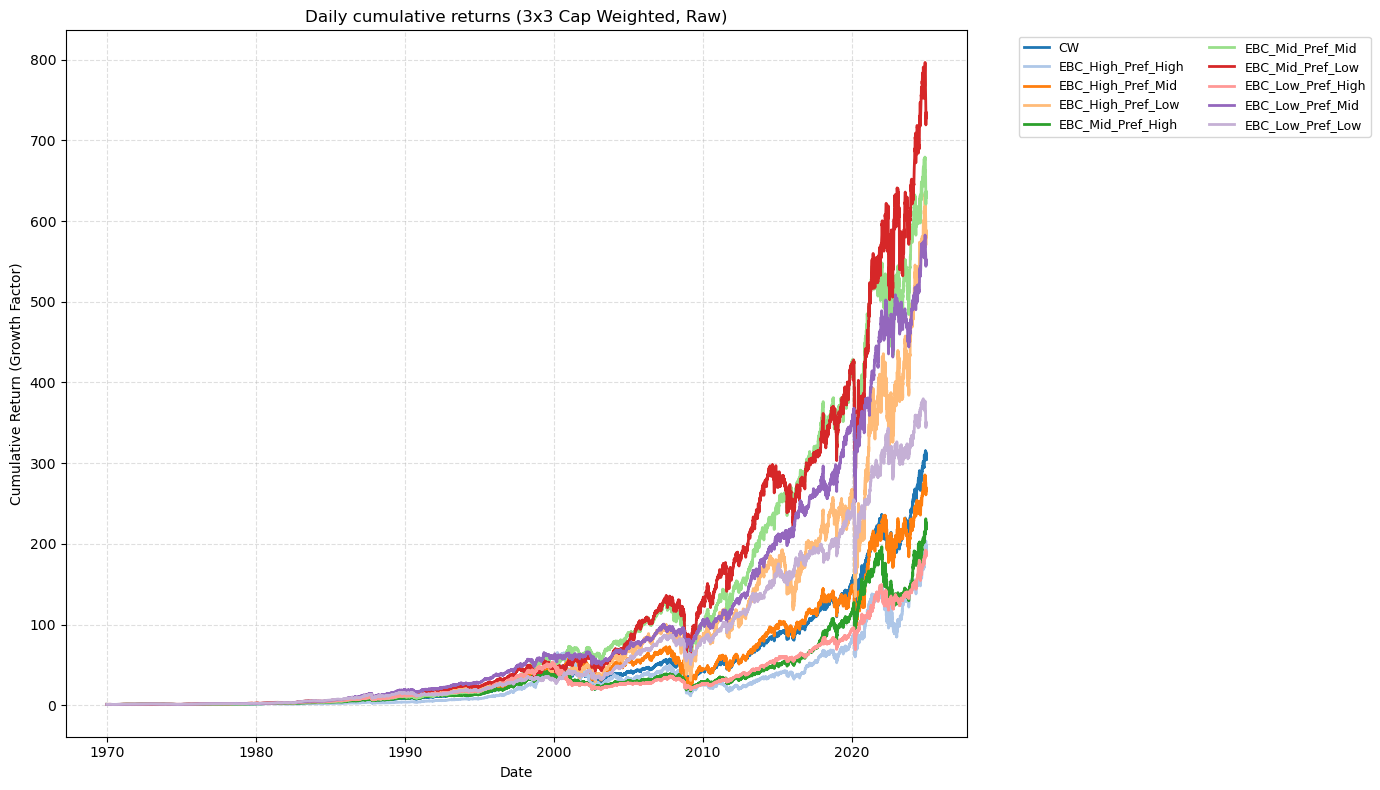

In [21]:
#full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

fmb_plots.plot_cum_returns(cw_complete_df[selected_columns], title=f"Daily cumulative returns ({n_q1}x{n_q2} Cap Weighted, Raw)", log=False)

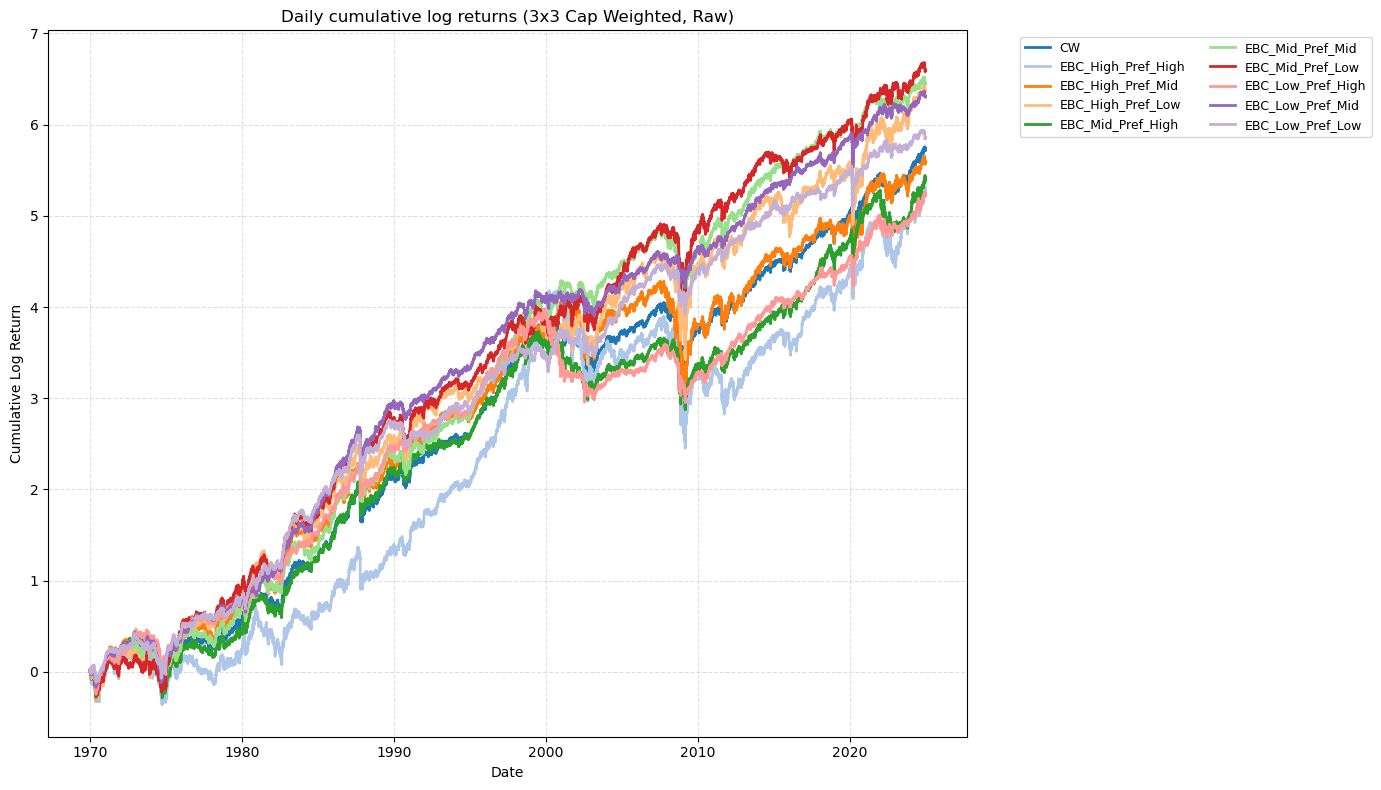

In [22]:
fmb_plots.plot_cum_returns(cw_complete_df[selected_columns], title=f"Daily cumulative log returns ({n_q1}x{n_q2} Cap Weighted, Raw)", log=True)

In [23]:
period = start_date[:4] + '_2024'
save_dir = DATA_PROCESSED_DIR / 'daily'

daily_cw_quantile_returns = cw_complete_df[selected_columns]
daily_cw_quantile_returns.to_csv(save_dir / f"daily_{period}_cw_quantile_returns_{n_q1}x{n_q2}.csv")

In [24]:
# ── Benchmark: annualized geometric mean returns over the analysis period ──
cw_geo = np.expm1(np.log1p(cw_complete_df['CW']).mean())
cw_ann = (1 + cw_geo) ** 252 - 1
print(f"Annualized Geometric Mean Return ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")

Annualized Geometric Mean Return (1969–2024)
  CW (ours) : 10.95%


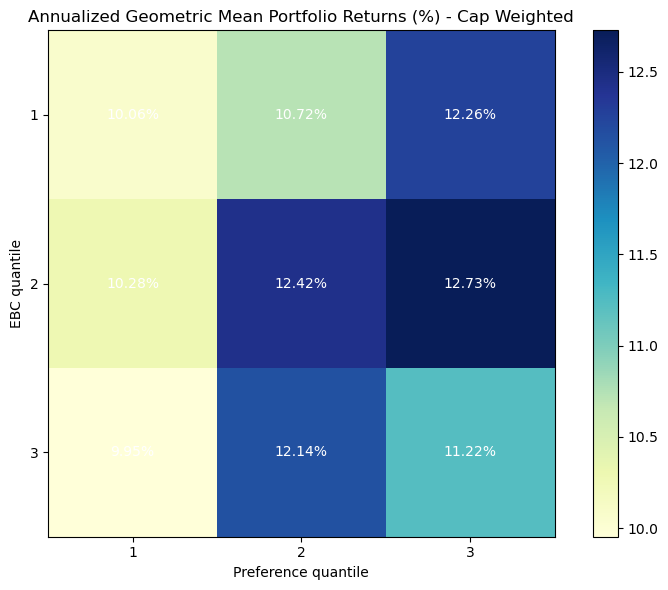

In [25]:
# True geometric mean grid (annualized as (1+geo_daily)^252 − 1)
cw_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    cw_results["mean_grid"], annualize=True, frequency='daily', cw=True, geometric=True,
    portrets_wide=cw_portrets_raw
)

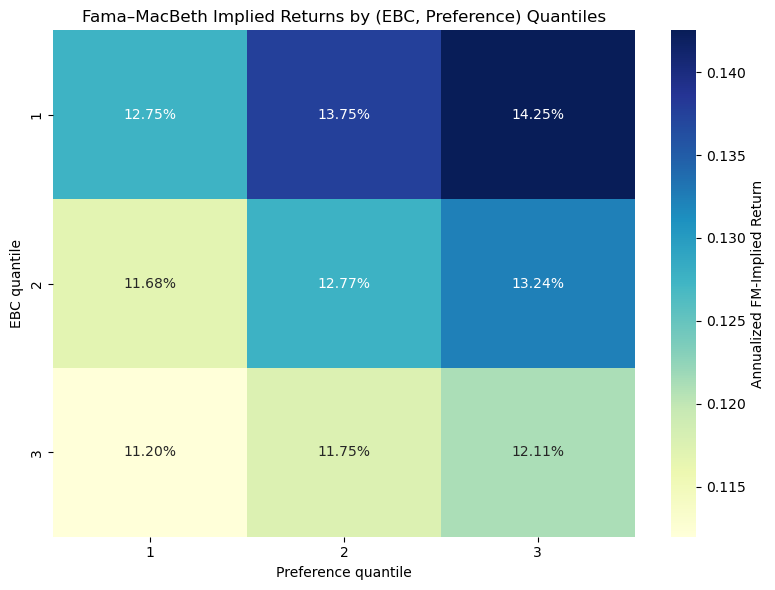

In [26]:
cw_implied_mean_grid = fmb_plots.plot_expected_return_grid(cw_results["pricing"], cw_results["fm_table"], n_q1, n_q2,frequency = 'daily')

## turnover

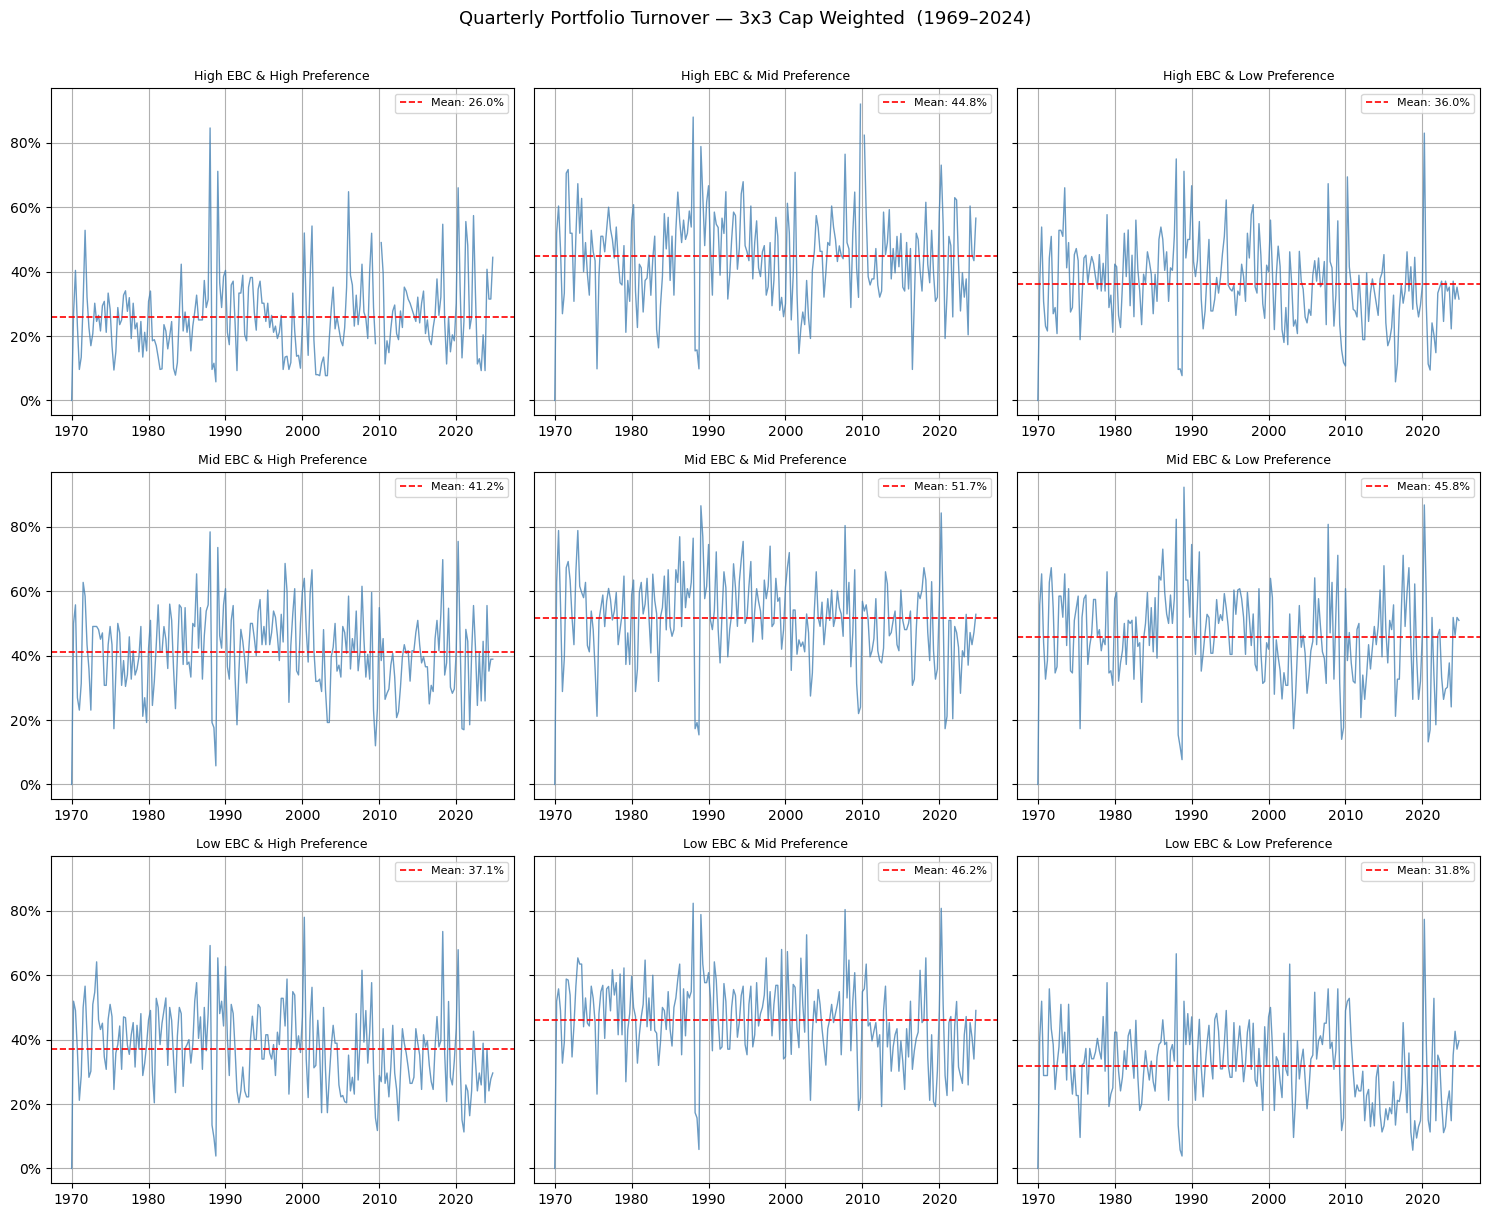

Average Turnover by Portfolio Cell (Cap Weighted):


,Avg Quarterly Turnover,Annualized Turnover
High EBC & High Preference,0.2596,1.0382
High EBC & Mid Preference,0.4477,1.7910
High EBC & Low Preference,0.3602,1.4410
Mid EBC & High Preference,0.4124,1.6495
Mid EBC & Mid Preference,0.5167,2.0670
Mid EBC & Low Preference,0.4577,1.8309
Low EBC & High Preference,0.3712,1.4846
Low EBC & Mid Preference,0.4622,1.8487
Low EBC & Low Preference,0.3184,1.2735


Saved: daily_1969_2024_turnover_3x3.csv


In [27]:
# ── Portfolio Turnover (Cap Weighted) ─────────────────────────────────────
members_cw = cw_results["members"].copy()
m = members_cw.reset_index()
m['period'] = m['date'].dt.to_period('Q')
first_date_per_period = m.groupby('period')['date'].min()
m_first = m[m['date'].isin(first_date_per_period.values)]

# Dynamic portfolio names derived from portrets_wide column order
_cw_cols = list(cw_results['portrets_wide'].columns)
portfolio_names = {
    (q1, q2): _cw_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [28]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'daily',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

ew_results["mean_grid"]*252

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the re

,1,2,3
1,0.147275,0.147996,0.166059
2,0.129291,0.142366,0.146690
3,0.116762,0.129736,0.130817


In [29]:
# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
ew_portrets_raw = ew_results['portrets_wide'].copy()
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)

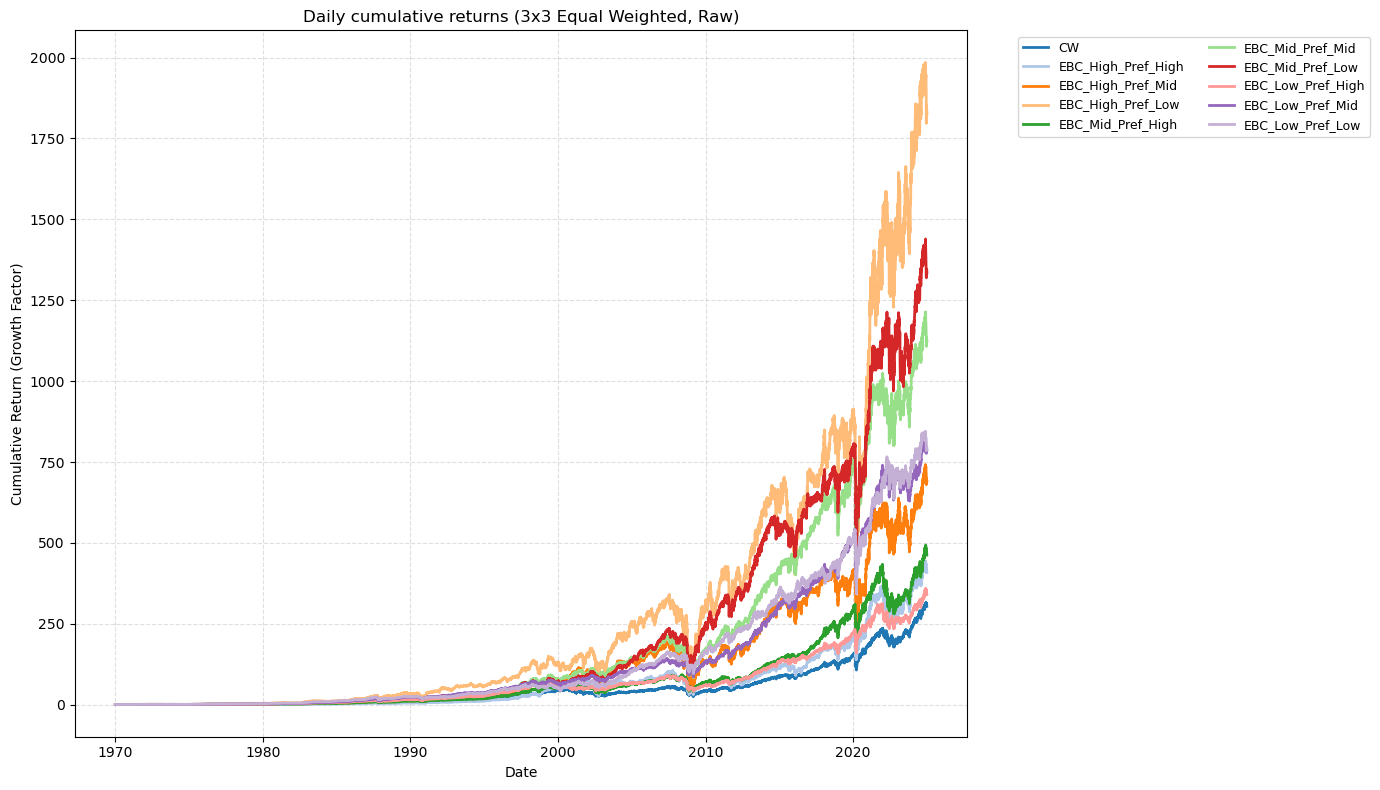

In [30]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Daily cumulative returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=False)

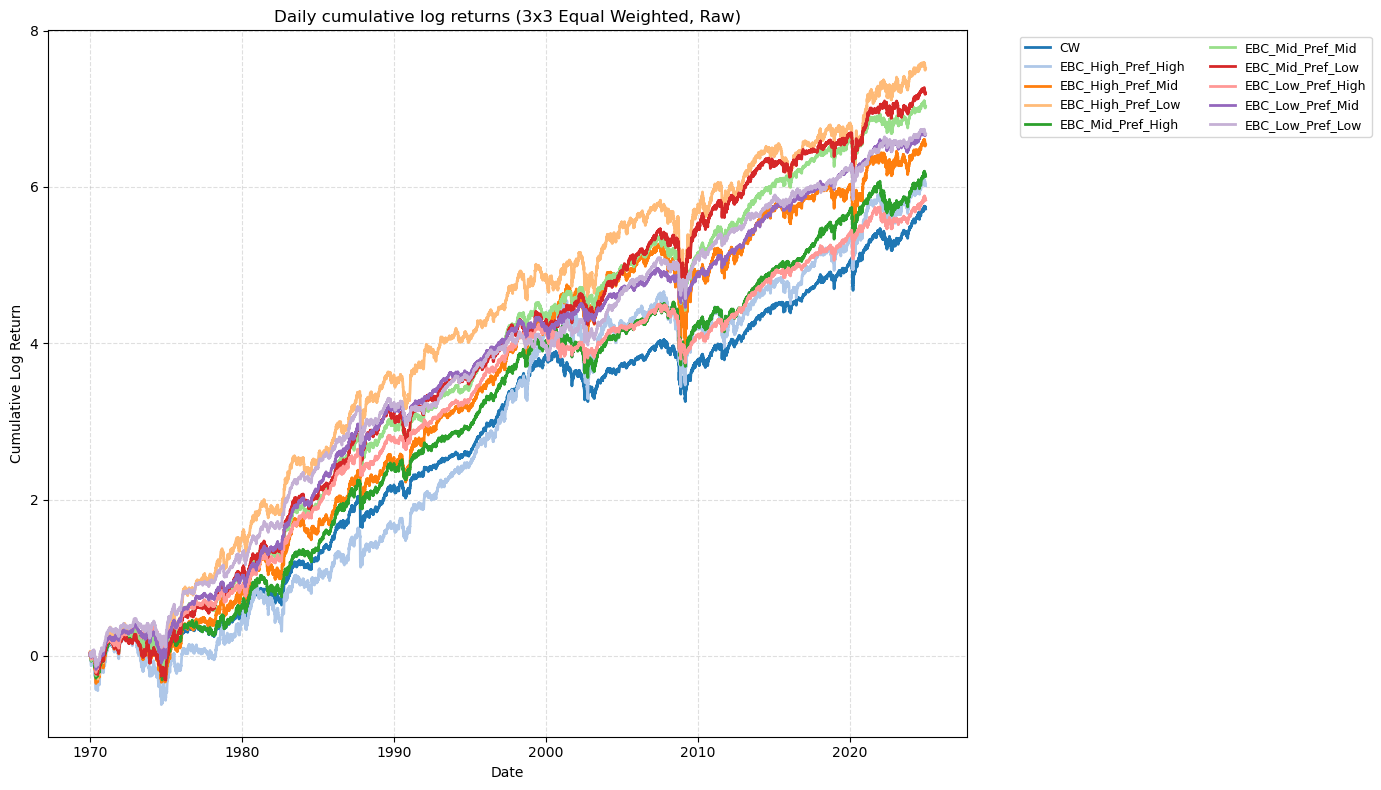

In [31]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Daily cumulative log returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=True)

In [32]:
daily_ew_quantile_returns = ew_complete_df[selected_columns]
period = start_date[:4] + '_2024'

save_dir = DATA_PROCESSED_DIR / 'daily'

daily_ew_quantile_returns.to_csv(save_dir / f"daily_{period}_ew_quantile_returns_{n_q1}x{n_q2}.csv")

In [33]:
# ── Benchmark: annualized geometric mean returns over the analysis period ──
cw_geo = np.expm1(np.log1p(cw_complete_df['CW']).mean())
cw_ann = (1 + cw_geo) ** 252 - 1
print(f"Annualized Geometric Mean Return ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")

Annualized Geometric Mean Return (1969–2024)
  CW (ours) : 10.95%


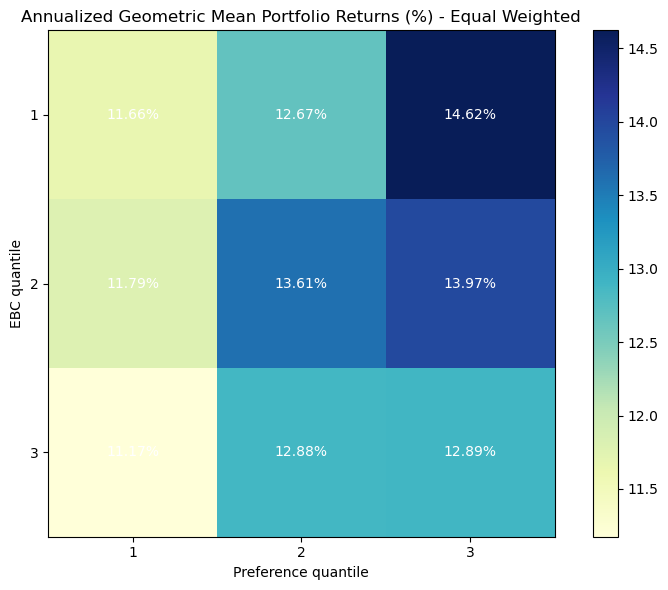

In [34]:
# True geometric mean grid (annualized as (1+geo_daily)^252 − 1)
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    ew_results["mean_grid"], annualize=True, frequency='daily', cw=False, geometric=True,
    portrets_wide=ew_portrets_raw
)

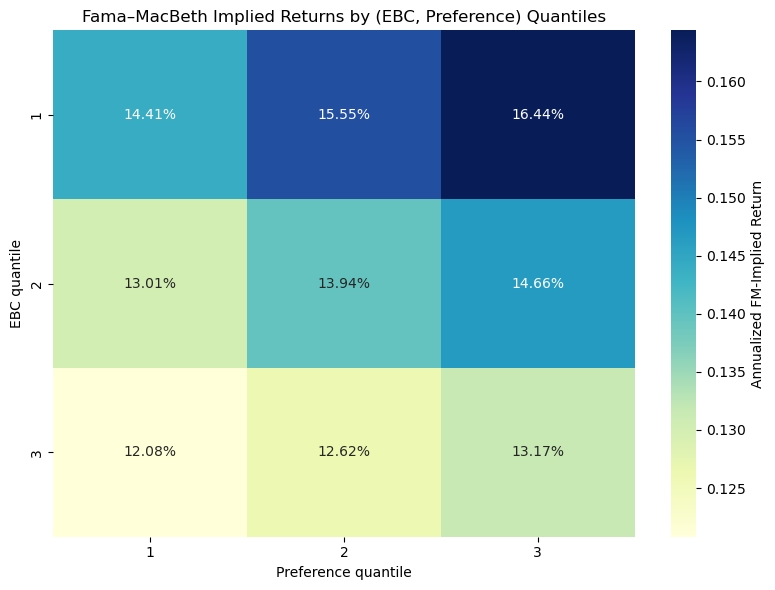

In [35]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2,frequency = 'daily')

# <span style="color:red"> Transaction Costs — EW & CW Quantile Portfolios </span>

**Formula (Invesco):** `TC = 2 × Turnover × ONE_WAY_COST`

Rebalancing is **quarterly**. The cost is deducted on the **first trading day** of each new quarter.
Non-rebalancing days are unaffected.

> Adjust `ONE_WAY_COST` below to change the assumption.

In [46]:
ONE_WAY_COST = 0.0005  # bps per side — change here to update everything below

# ── Step 1: EW turnover (from member assignments) ─────────────────────────
members_ew = ew_results["members"].copy()
m_ew = members_ew.reset_index()
m_ew['period'] = m_ew['date'].dt.to_period('Q')
first_date_per_period_ew = m_ew.groupby('period')['date'].min()
m_ew_first = m_ew[m_ew['date'].isin(first_date_per_period_ew.values)]

# Dynamic names derived from portrets_wide column order
_ew_cols = list(ew_results['portrets_wide'].columns)
portfolio_names_ew = {
    (q1, q2): _ew_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

turnover_dict_ew = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_ew_first[(m_ew_first['q1'] == q1) & (m_ew_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_ew[portfolio_names_ew[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_ew = pd.DataFrame(turnover_dict_ew)
turnover_ew_q = turnover_ew.copy()
turnover_ew_q.index = pd.DatetimeIndex(turnover_ew_q.index).to_period('Q')

# ── Step 2: Helper — map quarterly TC to first monthly return of each quarter
def build_tc_monthly(gross_df, turnover_q_df, one_way_cost):
    monthly_quarters = gross_df.index.to_period('Q')
    first_month_of_quarter = {}
    for date, q in zip(gross_df.index, monthly_quarters):
        if q not in first_month_of_quarter:
            first_month_of_quarter[q] = date
    tc = pd.DataFrame(0.0, index=gross_df.index, columns=gross_df.columns)
    for col in turnover_q_df.columns:
        if col not in tc.columns:
            continue
        for q_period, to_val in turnover_q_df[col].items():
            if q_period in first_month_of_quarter and not np.isnan(to_val):
                tc.loc[first_month_of_quarter[q_period], col] = 2 * to_val * one_way_cost
    return tc

# ── Step 3: Apply TC to both EW and CW portfolios ─────────────────────────
ew_gross = ew_results['portrets_wide'].copy()
cw_gross = cw_results['portrets_wide'].copy()

ew_tc = build_tc_monthly(ew_gross, turnover_ew_q, ONE_WAY_COST)
cw_tc = build_tc_monthly(cw_gross, turnover_ew_q, ONE_WAY_COST)

ew_net = ew_gross - ew_tc
cw_net = cw_gross - cw_tc

print(f"One-way cost : {ONE_WAY_COST*10_000:.1f} bps  |  Round-trip per 100% turnover: {2*ONE_WAY_COST*100:.2f}%")
print(f"\nMean quarterly TC per EW portfolio (bps):")
print((ew_tc[ew_tc > 0].mean() * 10_000).round(2).to_string())

One-way cost : 50.0 bps  |  Round-trip per 100% turnover: 1.00%

Mean quarterly TC per EW portfolio (bps):
EBC_High_Pref_High    26.08
EBC_High_Pref_Mid     44.98
EBC_High_Pref_Low     36.19
EBC_Mid_Pref_High     41.43
EBC_Mid_Pref_Mid      51.91
EBC_Mid_Pref_Low      45.98
EBC_Low_Pref_High     37.28
EBC_Low_Pref_Mid      46.43
EBC_Low_Pref_Low      31.98


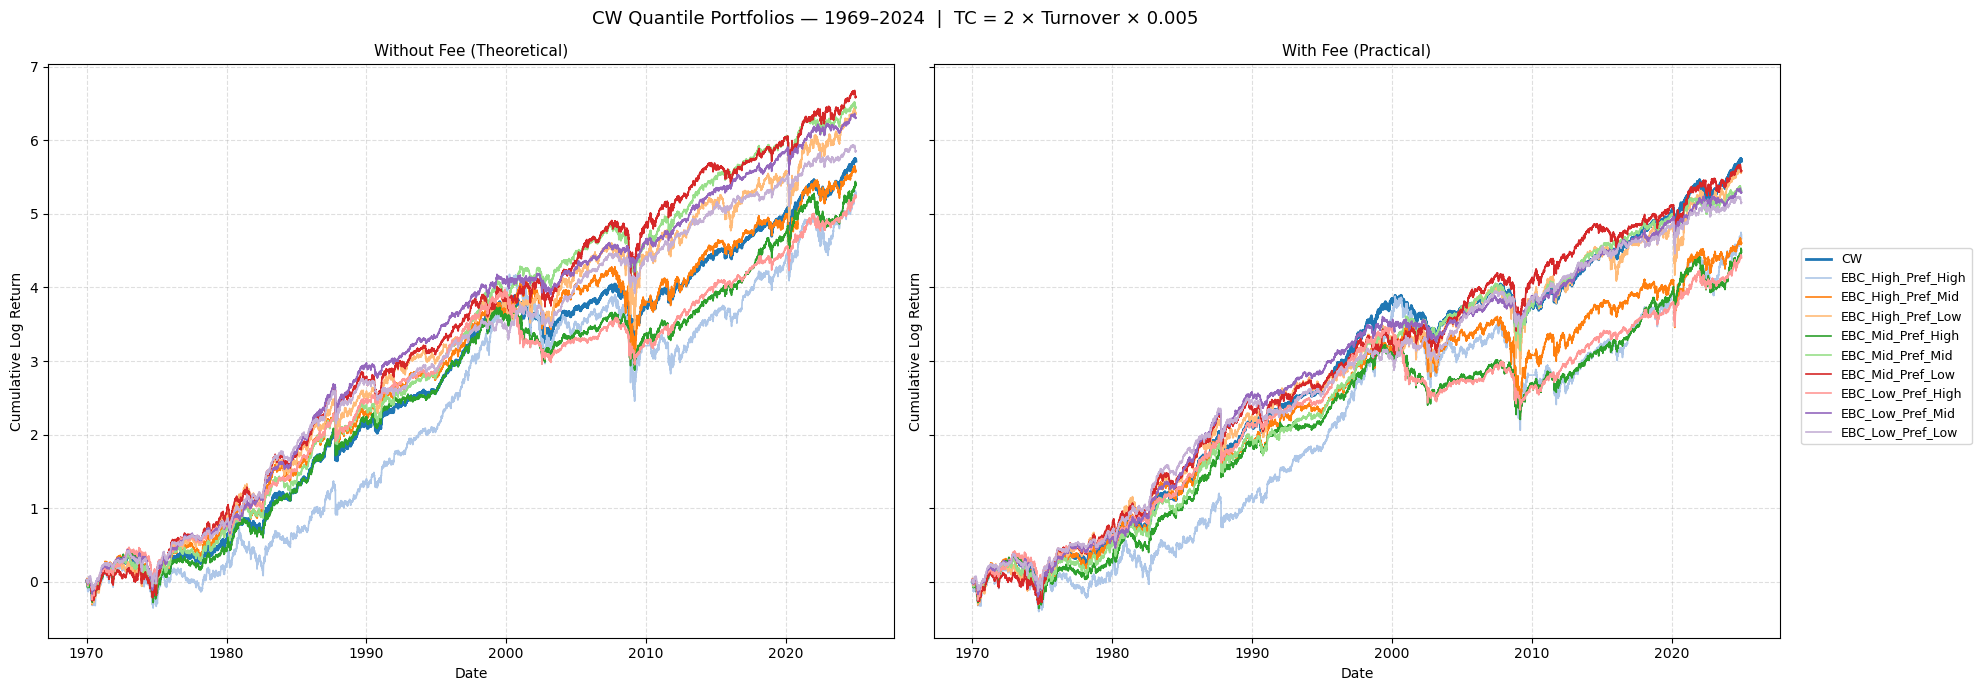

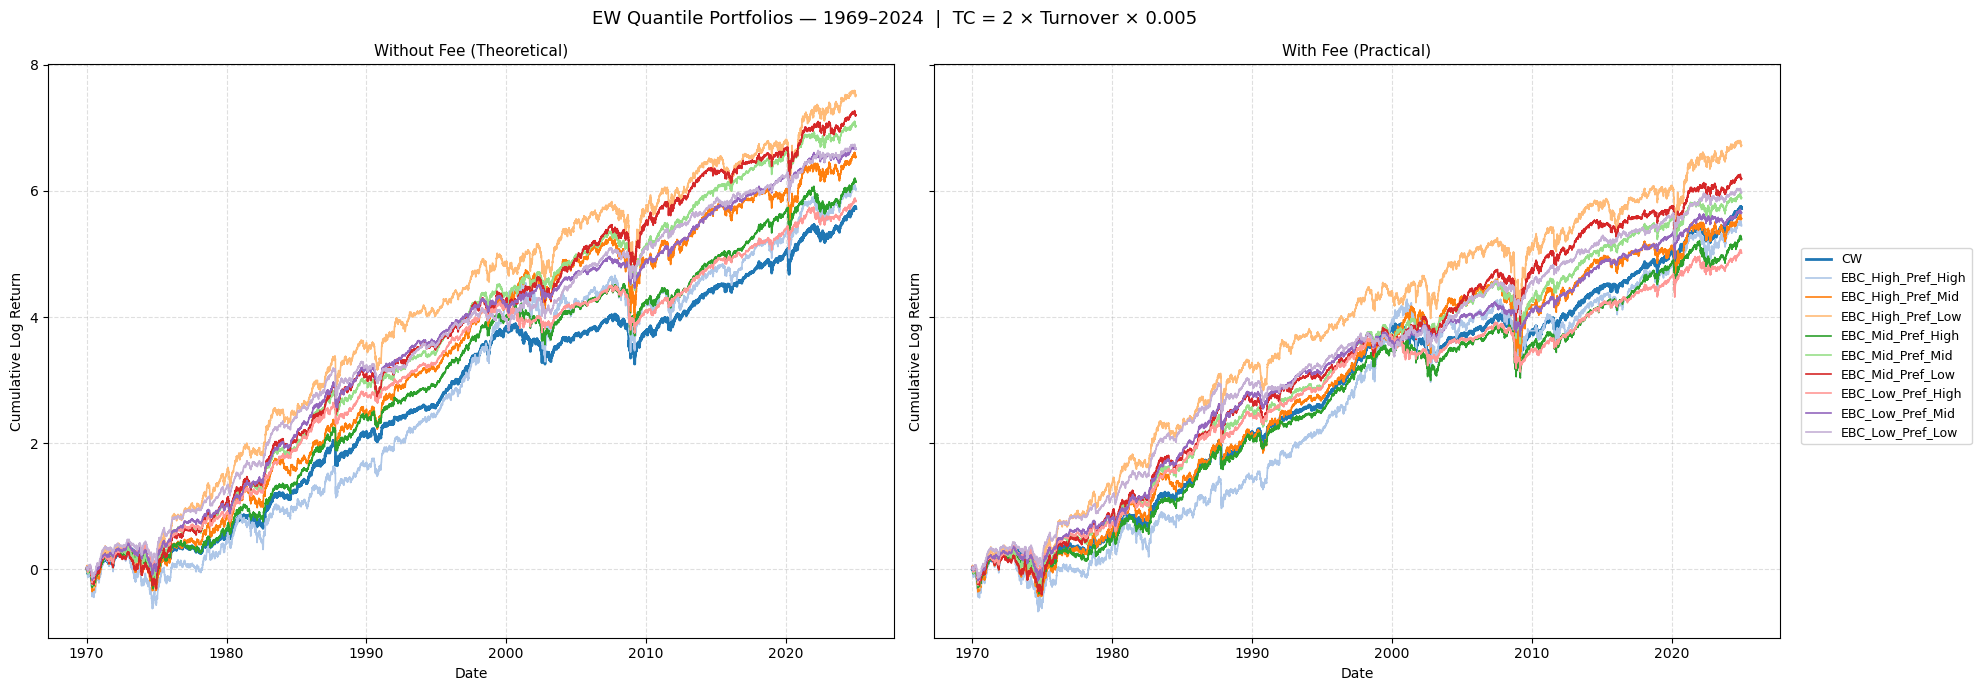

In [47]:
# ── Gross vs Net side-by-side (log cumulative returns) ────────────────────
# Left  = Without fee (theoretical)  |  Right = With fee (practical)

palette = plt.cm.tab20.colors
bench_color = palette[0]
port_colors = palette[1:10]

port_cols = list(ew_gross.columns)

bench = cw_complete_df['CW'].dropna()
bench_logcum = np.log1p(bench).cumsum()

def plot_gross_net_side_by_side_daily(gross_df, net_df, bench_logcum, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, df, subtitle in zip(axes,
                                [gross_df, net_df],
                                ["Without Fee (Theoretical)", "With Fee (Practical)"]):
        ax.plot(bench_logcum.index, bench_logcum.values,
                color=bench_color, linewidth=2, label='CW')
        for col, color in zip(port_cols, port_colors):
            lc = np.log1p(df[col].dropna()).cumsum()
            ax.plot(lc.index, lc.values, color=color, linewidth=1.2, label=col)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Log Return")
        ax.grid(True, linestyle='--', alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=1, fontsize=9,
               bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_gross_net_side_by_side_daily(
    cw_gross, cw_net, bench_logcum,
    f"CW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

plot_gross_net_side_by_side_daily(
    ew_gross, ew_net, bench_logcum,
    f"EW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

In [48]:
# ── Summary: Gross vs Net annualized geometric mean returns ───────────────
def tc_summary_daily(gross_df, net_df, tc_df, label):
    rows = []
    for col in gross_df.columns:
        ann_gross = (1 + np.expm1(np.log1p(gross_df[col].dropna()).mean())) ** 252 - 1
        ann_net   = (1 + np.expm1(np.log1p(net_df[col].dropna()).mean())) ** 252 - 1
        avg_ann_tc = tc_df[col][tc_df[col] > 0].mean() * 4  # 4 quarters/year
        rows.append({
            "Portfolio": col.replace("EBC_", "").replace("_", " "),
            "Gross Ann.": f"{ann_gross:.2%}",
            "Net Ann.":   f"{ann_net:.2%}",
            "TC Drag (bps)": f"{(ann_gross - ann_net)*10_000:.1f}",
            "Avg Ann. TC (bps)": f"{avg_ann_tc*10_000:.1f}",
        })
    df = pd.DataFrame(rows).set_index("Portfolio")
    print(f"\n{'─'*60}")
    print(f"  {label}  |  {ONE_WAY_COST*10_000:.0f}bps/side  |  Formula: 2 × Turnover × {ONE_WAY_COST}")
    print(f"{'─'*60}")
    display(df)

tc_summary_daily(ew_gross, ew_net, ew_tc, "EW Quantile Portfolios")
tc_summary_daily(cw_gross, cw_net, cw_tc, "CW Quantile Portfolios")


────────────────────────────────────────────────────────────
  EW Quantile Portfolios  |  50bps/side  |  Formula: 2 × Turnover × 0.005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref High,11.66%,10.51%,115.3,104.3
High Pref Mid,12.67%,10.67%,200.1,179.9
High Pref Low,14.62%,12.98%,163.9,144.8
Mid Pref High,11.79%,9.96%,183.0,165.7
Mid Pref Mid,13.61%,11.29%,232.6,207.6
Mid Pref Low,13.97%,11.91%,206.8,183.9
Low Pref High,11.17%,9.54%,163.8,149.1
Low Pref Mid,12.88%,10.81%,206.7,185.7
Low Pref Low,12.89%,11.46%,142.8,127.9



────────────────────────────────────────────────────────────
  CW Quantile Portfolios  |  50bps/side  |  Formula: 2 × Turnover × 0.005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref High,10.06%,8.93%,113.6,104.3
High Pref Mid,10.72%,8.75%,196.6,179.9
High Pref Low,12.26%,10.65%,160.6,144.8
Mid Pref High,10.28%,8.48%,180.4,165.7
Mid Pref Mid,12.42%,10.12%,230.1,207.6
Mid Pref Low,12.73%,10.68%,204.6,183.9
Low Pref High,9.95%,8.33%,162.0,149.1
Low Pref Mid,12.14%,10.09%,205.4,185.7
Low Pref Low,11.22%,9.82%,140.7,127.9


# <span style="color:red"> Extra Stats

In [39]:
# 1. Annualized Sharpe Ratio (Daily)
# We use 252 for daily and 12 for monthly
daily_rets = daily_cw_quantile_returns
sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)

# 2. Maximum Drawdown
# Calculate cumulative growth from $1
cum_rets = (1 + daily_rets).cumprod()
running_max = cum_rets.cummax()
drawdown = (cum_rets - running_max) / running_max
max_dd = drawdown.min()

performance = pd.DataFrame({
    "Ann. Return (%)": daily_rets.mean() * 252 * 100,
    "Ann. Volatility (%)": daily_rets.std() * np.sqrt(252) * 100,
    "Sharpe Ratio": sharpe,
    "Max Drawdown (%)": max_dd * 100
})

# Display sorted by Sharpe to see the most efficient portfolio
print("Portfolio Risk-Reward Summary:")
display(performance.sort_values("Sharpe Ratio", ascending=False).round(3))

Portfolio Risk-Reward Summary:


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
EBC_Low_Pref_Mid,12.330,13.134,0.939,-42.333
EBC_Low_Pref_Low,11.600,13.819,0.839,-42.208
EBC_Mid_Pref_Mid,13.206,17.241,0.766,-58.461
EBC_Mid_Pref_Low,13.564,17.741,0.765,-53.990
CW,11.859,17.090,0.694,-54.741
EBC_Low_Pref_High,10.723,15.668,0.684,-64.192
EBC_High_Pref_Low,14.268,23.231,0.614,-69.252
EBC_Mid_Pref_High,11.645,19.224,0.606,-58.364
EBC_High_Pref_Mid,12.909,23.316,0.554,-73.537
EBC_High_Pref_High,13.077,26.402,0.495,-82.208


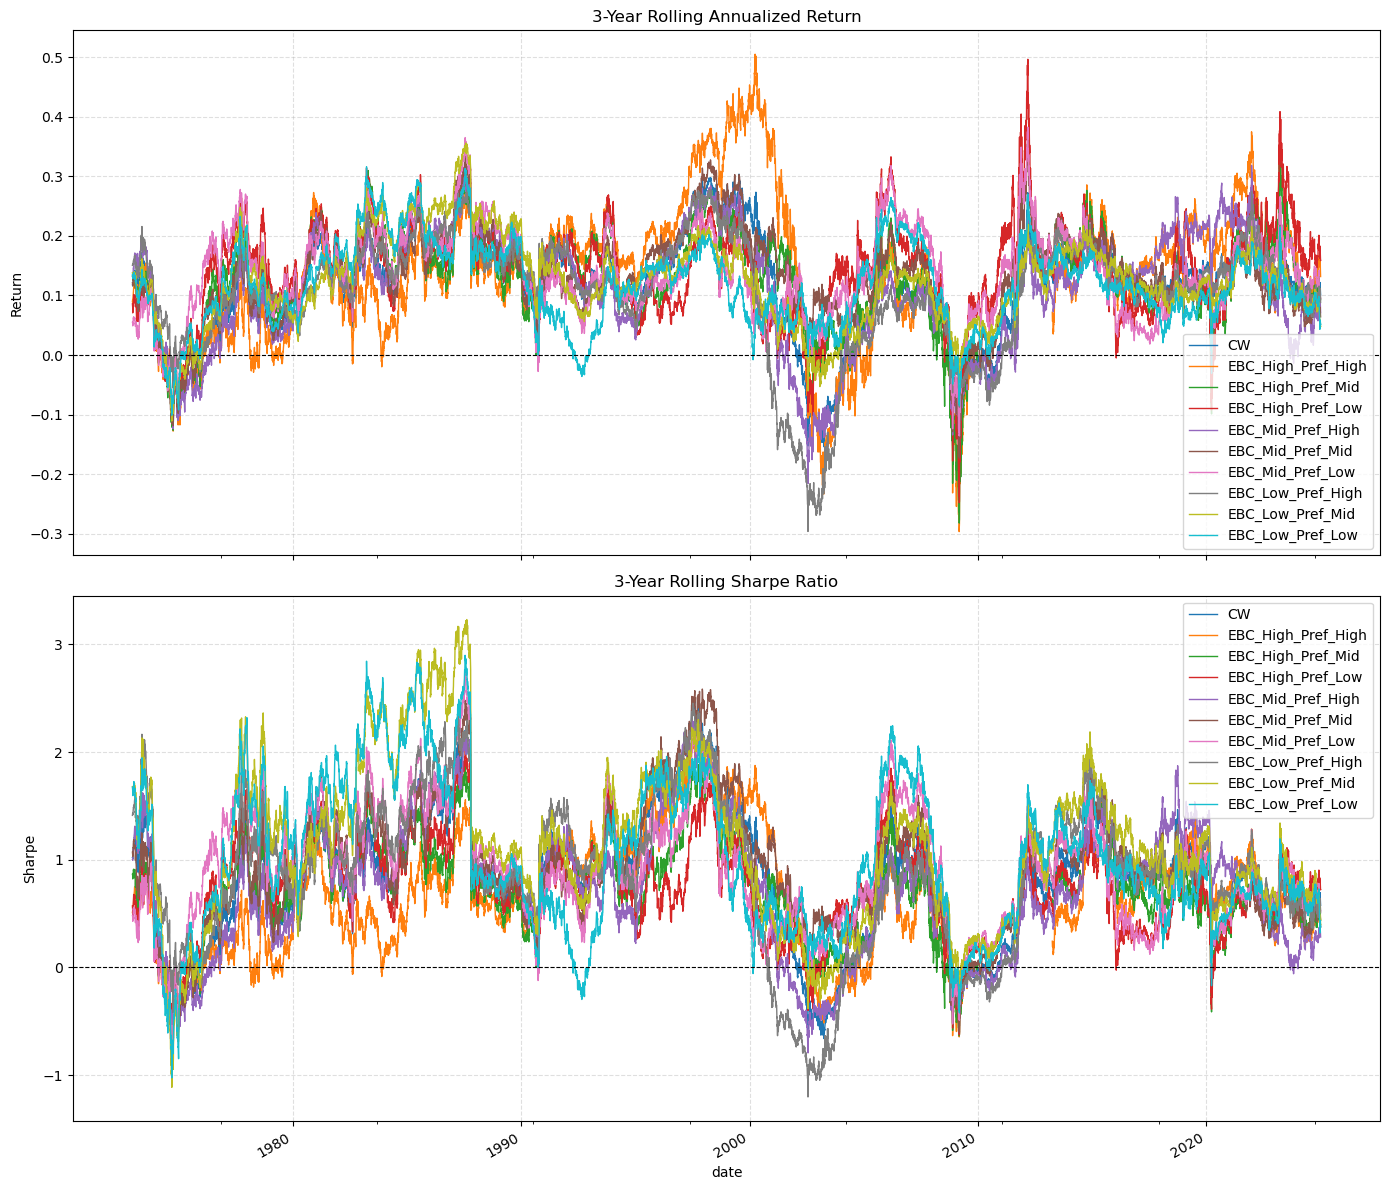

In [40]:
# Define window (252 days * 3 years)
window = 252 * 3

# 1. Rolling Annualized Returns
rolling_ann_ret = daily_rets.rolling(window=window).mean() * 252

# 2. Rolling Annualized Volatility
rolling_ann_vol = daily_rets.rolling(window=window).std() * np.sqrt(252)

# 3. Rolling Sharpe Ratio
rolling_sharpe = rolling_ann_ret / rolling_ann_vol

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

rolling_ann_ret.plot(ax=ax1, linewidth=1)
ax1.set_title("3-Year Rolling Annualized Return")
ax1.set_ylabel("Return")
ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax1.grid(True, linestyle="--", alpha=0.4)

rolling_sharpe.plot(ax=ax2, linewidth=1)
ax2.set_title("3-Year Rolling Sharpe Ratio")
ax2.set_ylabel("Sharpe")
ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# <span style="color:red">  Fitted GARCH

In [41]:
from arch import arch_model

In [42]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [43]:
cw_complete_df.columns

Index(['CW', 'EW', 'EBC', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'CW_RF', 'EW_RF', 'EBC_RF', 'CW-EW', 'CW-EBC', 'MKT',
       'EBC_High_Pref_High', 'EBC_High_Pref_Mid', 'EBC_High_Pref_Low',
       'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid', 'EBC_Mid_Pref_Low',
       'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid', 'EBC_Low_Pref_Low'],
      dtype='object')

In [44]:
portfolio_name = 'CW'

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                           CW   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -17780.2
Distribution:      Standardized Student's t   AIC:                           35570.4
Method:                  Maximum Likelihood   BIC:                           35608.1
                                              No. Observations:                13872
Date:                      Mon, Mar 23 2026   Df Residuals:                    13871
Time:                              05:42:35   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

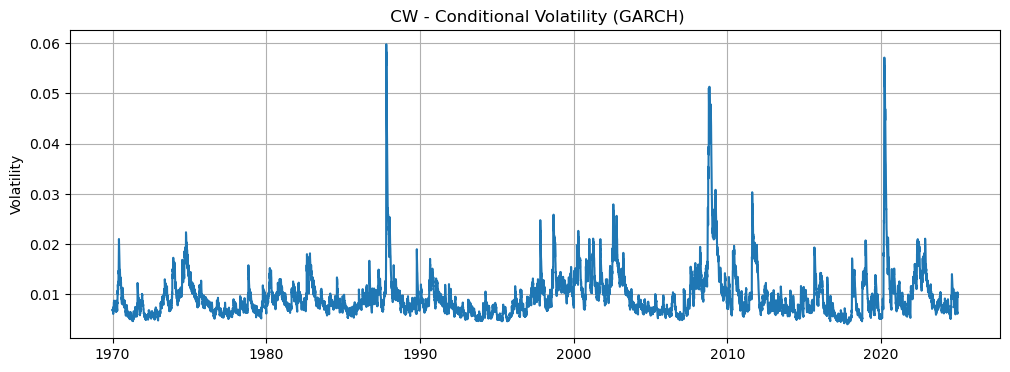

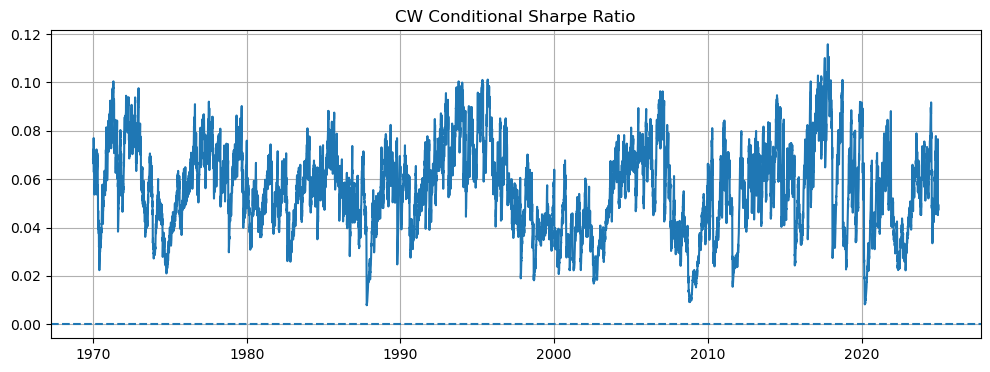

In [45]:
portfolio = cw_complete_df[portfolio_name]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()